# Chicago Airbnb and Socio-Economic Indicators

This notebook focuses on a geo-social visual analysis of information for the Chicago metropolitan area. The data is from ‘geodacenter’ and is part of the included datasets for the geodatasets python library. This project is intended as a high-level overview of the available data from Airbnb (taken October 2015) and social factors within each community. The dataset comprises Airbnb data up to October 2015, socio-economic data from 2008-2012, census data from 2010, and one year of crime data spanning 2014-2015.

All the Airbnb data contains averages or totals of an entire community. So for example, the price per person in Douglas community is an average of all the listings in that area. The room type is also an average, which is an interesting dilemma; Airbnb has a number system for the type of accommodation available, 1 = whole house/space, 2 = shared space, or 3 = shared room. Again, using Douglas as an example, the ‘room type’ average is 1.798474. This means there are likely more whole house and shared spaces listings than there are shared rooms. I attempted some visual analysis with the ‘room type’ but decided it didn’t provide the type of information the values are supposed to suggest. The values are more categorical than numeric, which means an average of all the listings is, in some ways, meaningless.


# Data Information

### Census Data: 2008 – 2012

- crowded: percent of occupied housing units with more than one person per room (i.e., crowded housing)
- poverty: the percent of households living below the federal poverty level
- unemployed: the percent of persons in the labor force over the age of 16 years that are unemployed
- without_hs: the percent of persons over the age of 25 years without a high school diploma
- dependency: the percent of the population under 18 or over 64 years of age (i.e., dependency)
- income_pc: per-capita income.
- hardship_in: hardship index (Score that incorporates each of the six selected socioeconomic indicators (see dataset description))
- community: name of community area
- AREAID: ID number associated with the community area
- population: community area population as of 2010 census

### Airbnb Data: 2015

Airbnb Columns:
- price_pp: price per person to stay in Airbnb (avg)
- rev_rating: host's rating (avg)
- num_spots: number of Airbnb spots
- response_r: response rate of airbnb host
- accept_r: acceptance rate of airbnb host
- room_type: 1 is entire home, 2 is private room, 3 is shared room (avg of each community)
- shape_area: polygon area
- shape_len: polygon perimeter

### Chicage Crime Data: 2014-2015
- num_crimes: total number of crimes (battery, burglary, gambling, homicide, kidnapping, robbery, stalking, homicide, and theft, etc.
- num_theft: totoal number of thefts

## Data Sources

Information about dataset: 
- https://geodacenter.github.io/data-and-lab/airbnb/

Information about the Chicage socio-economic data: 
- https://data.cityofchicago.org/Health-Human-Services/Census-Data-Selected-socioeconomic-indicators-in-C/kn9c-c2s2/about_data

## Imports

In [1]:
import geopandas as gpd
import geodatasets
import contextily as ctx

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

from scipy import stats

import pandas as pd

import numpy as np

import warnings
warnings.filterwarnings("ignore", "Numba not installed", category=UserWarning)

## Data - Geodataset "airbnb"

In [2]:
# data from Chicago airbnb rentals from geopandas - geodatasets
dataset_name = "geoda.airbnb"
dataset_info = geodatasets.data.query_name(dataset_name)
print(dataset_info["description"])

Airbnb rentals, socioeconomics, and crime in Chicago


In [3]:
# get data from geodatasets and view column names
path = geodatasets.get_path(dataset_name)
data = gpd.read_file(path)
print(data.columns)

Index(['community', 'shape_area', 'shape_len', 'AREAID', 'response_r',
       'accept_r', 'rev_rating', 'price_pp', 'room_type', 'num_spots',
       'poverty', 'crowded', 'dependency', 'without_hs', 'unemployed',
       'income_pc', 'harship_in', 'num_crimes', 'num_theft', 'population',
       'geometry'],
      dtype='str')


In [4]:
# quick glance at the dataframe
data.head()

,community,shape_area,shape_len,AREAID,response_r,accept_r,rev_rating,price_pp,room_type,num_spots,...,crowded,dependency,without_hs,unemployed,income_pc,harship_in,num_crimes,num_theft,population,geometry
0,DOUGLAS,46004621.1581,31027.0545098,35,98.771429,94.514286,87.777778,78.157895,1.789474,38,...,1.8,30.7,14.3,18.2,23791,47,5013,1241,18238,"POLYGON ((-87.60914 41.84469, -87.60915 41.844..."
1,OAKLAND,16913961.0408,19565.5061533,36,99.200000,90.105263,88.812500,53.775000,1.850000,20,...,1.3,40.4,18.4,28.7,19252,78,1306,311,5918,"POLYGON ((-87.59215 41.81693, -87.59231 41.816..."
2,FULLER PARK,19916704.8692,NaN,37,68.000000,NaN,91.750000,84.000000,1.833333,6,...,3.2,44.9,26.6,33.9,10432,97,1764,383,2876,"POLYGON ((-87.6288 41.80189, -87.62879 41.8017..."
3,GRAND BOULEVARD,48492503.1554,28196.8371573,38,94.037037,83.615385,92.750000,119.533333,1.533333,30,...,3.3,39.5,15.9,24.3,23472,57,6416,1428,21929,"POLYGON ((-87.60671 41.81681, -87.6067 41.8165..."
4,KENWOOD,29071741.9283,23325.1679062,39,92.542857,88.142857,90.656250,77.991453,1.615385,39,...,2.4,35.4,11.3,15.7,35911,26,2713,654,17841,"POLYGON ((-87.59215 41.81693, -87.59215 41.816..."


In [5]:
# get info on the columns, NaN values, and dtypes
data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   community   77 non-null     str     
 1   shape_area  77 non-null     str     
 2   shape_len   76 non-null     str     
 3   AREAID      77 non-null     int64   
 4   response_r  68 non-null     float64 
 5   accept_r    67 non-null     float64 
 6   rev_rating  67 non-null     float64 
 7   price_pp    69 non-null     float64 
 8   room_type   69 non-null     float64 
 9   num_spots   77 non-null     int64   
 10  poverty     77 non-null     float64 
 11  crowded     77 non-null     float64 
 12  dependency  77 non-null     float64 
 13  without_hs  77 non-null     float64 
 14  unemployed  77 non-null     float64 
 15  income_pc   77 non-null     int64   
 16  harship_in  77 non-null     int64   
 17  num_crimes  77 non-null     int64   
 18  num_theft   77 non-null     int64   
 19  po

In [6]:
# fix column spelling for hardship index
data = data.rename(columns={"harship_in": "hardship_in"})

### Airbnb Stats

In [7]:
# airbnb statistical summary
data[['response_r', 'accept_r', 'rev_rating', 'price_pp', 'room_type', 'num_spots']].describe()

,response_r,accept_r,rev_rating,price_pp,room_type,num_spots
count,68.000000,67.000000,67.000000,69.000000,69.000000,77.000000
mean,94.345761,89.465195,92.634557,73.863524,1.717848,65.272727
std,6.515507,13.726740,3.692742,35.211654,0.401049,142.899361
min,68.000000,0.000000,80.000000,14.000000,1.000000,0.000000
25%,92.339982,85.968750,91.000000,52.700000,1.483131,2.000000
50%,95.072700,91.142857,93.223368,70.000000,1.654545,7.000000
75%,100.000000,97.333333,94.833839,85.860424,2.000000,39.000000
max,100.000000,100.000000,100.000000,176.375604,3.000000,741.000000


Notes: There are up to 10 rows of missing data from Airbnb; there probably weren’t any listings when the data was downloaded in 2015. The ‘num_spots’ (number of listings) contains a wide spread: the median is 7 listings, most communities have less than 40 listings total, and some areas have several hundred. The price per person varies widely as well, from `$14` to `$176.38` per night.

### Socio-Economic Stats

In [8]:
# socio-economic statistical summary
data[['poverty', 'crowded', 'dependency', 'without_hs', 'unemployed', 
      'income_pc', 'hardship_in','population']].describe()

,poverty,crowded,dependency,without_hs,unemployed,income_pc,hardship_in,population
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,21.766234,4.923377,35.746753,20.341558,15.372727,25563.168831,49.506494,35007.766234
std,11.529957,3.682887,7.327716,11.823152,7.543412,15293.098259,28.690556,22361.945576
min,3.300000,0.300000,13.500000,2.500000,4.700000,8201.000000,1.000000,2876.000000
25%,13.200000,2.300000,32.000000,11.800000,9.200000,15754.000000,25.000000,18109.000000
50%,18.900000,3.800000,38.100000,18.500000,13.900000,21323.000000,50.000000,31028.000000
75%,29.200000,6.800000,40.500000,26.600000,20.000000,28887.000000,74.000000,48743.000000
max,56.500000,15.800000,51.500000,54.800000,35.900000,88669.000000,98.000000,98514.000000


In [9]:
max_without_hs = data.sort_values("without_hs", ascending=False).head(1)
max_without_hs = max_without_hs[["community", "without_hs", "poverty", "hardship_in"]]
max_without_hs

,community,without_hs,poverty,hardship_in
31,SOUTH LAWNDALE,54.8,30.7,96


Notes: The social and economic factors tend to be a percentage of the population within an area. For instance, the values for South Lawndale show that 54.8% of the population do not have a high school diploma, has a poverty rate of 30.7%, and a very high hardship index, 96. The hardship index is based on the other social factors (poverty, amount of dependents living at home, unemployment, etc).

### Crime Stats

In [10]:
# change num_crimes column name
data = data.rename(columns={"num_crimes": "total_crimes"})

# add column of all crimes other than theft (remove thefts from the value)
data["num_non_theft"] = data["total_crimes"] - data["num_theft"]

In [11]:
# crime statistical summary
data[["total_crimes", "num_theft", "num_non_theft"]].describe()

,total_crimes,num_theft,num_non_theft
count,77.000000,77.000000,77.000000
mean,6870.077922,1527.350649,5342.727273
std,5879.232012,1646.569526,4810.276000
min,537.000000,104.000000,433.000000
25%,2707.000000,568.000000,2035.000000
50%,4894.000000,1081.000000,3815.000000
75%,9951.000000,1748.000000,7595.000000
max,34365.000000,8783.000000,29923.000000


Notes: The crime data is interesting because the values were originally split into two groups (columns): total number of crimes (includes many different types of crimes including thefts) and total number of thefts. I changed the name of ‘num_crimes’ to ‘total_crimes’ and added a column of ‘num_non_theft’ to split these into truly unique values in each column.

## Airbnb Data

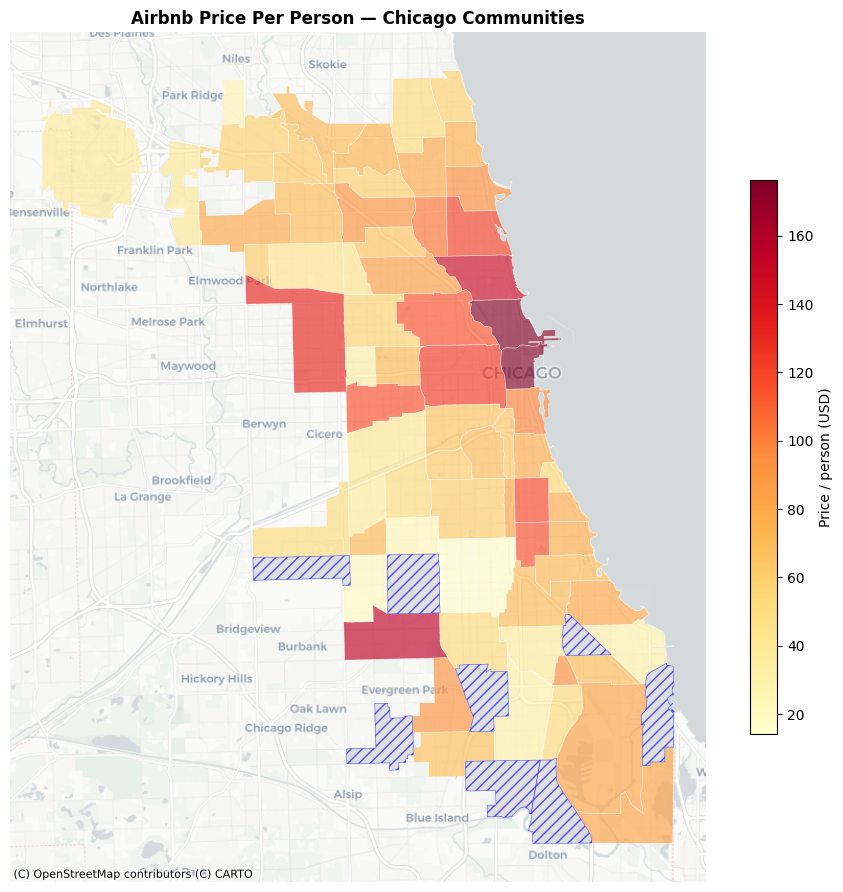

In [14]:
# basemap of chicago area under a choropleth of the airbnb price per person

data_web = data.to_crs(epsg=3857)   # Web Mercator required by contextily

fig, ax = plt.subplots(figsize=(9, 9))
data_web.plot(
    column="price_pp", cmap="YlOrRd", alpha=0.65, legend=True,
    edgecolor="white", linewidth=0.4, ax=ax,
    legend_kwds={"label": "Price / person (USD)", "shrink": 0.65},
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "blue",
        "hatch": "///",
        "label": "Missing Values"
    }
)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title("Airbnb Price Per Person — Chicago Communities",
             fontsize=12, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("images/1_abnb_a_basemap_price.png", bbox_inches="tight")
plt.show()

Notes: Most areas are light yellow to orange, suggesting most communities listed Airbnb’s for less than $80 per person in 2015.

In [15]:
# stats on price per person
print(f"The maximum price per person:        ${round(data["price_pp"].max(), 2)}")
print(f"The minimum price per person:        ${data["price_pp"].min()}")
print(f"The average price per person:        ${round(data["price_pp"].mean(), 2)}")
print(f"The median price per person:         ${data["price_pp"].median()}")

The maximum price per person:        $176.38
The minimum price per person:        $14.0
The average price per person:        $73.86
The median price per person:         $70.0


In [16]:
top_5_prices = data.sort_values("price_pp", ascending=False).head()
top_5_prices = top_5_prices[["community", "price_pp"]]
top_5_prices

,community,price_pp
36,NEAR NORTH SIDE,176.375604
37,LOOP,176.131821
68,ASHBURN,155.000000
67,LINCOLN PARK,149.147253
25,AUSTIN,131.175000


In [17]:
bottom_5_prices = data.sort_values("price_pp").head()
bottom_5_prices = bottom_5_prices[["community", "price_pp"]]
bottom_5_prices

,community,price_pp
64,WEST ENGLEWOOD,14.000000
65,ENGLEWOOD,16.194444
62,WEST LAWN,20.333333
60,GAGE PARK,23.593750
76,EDISON PARK,25.000000


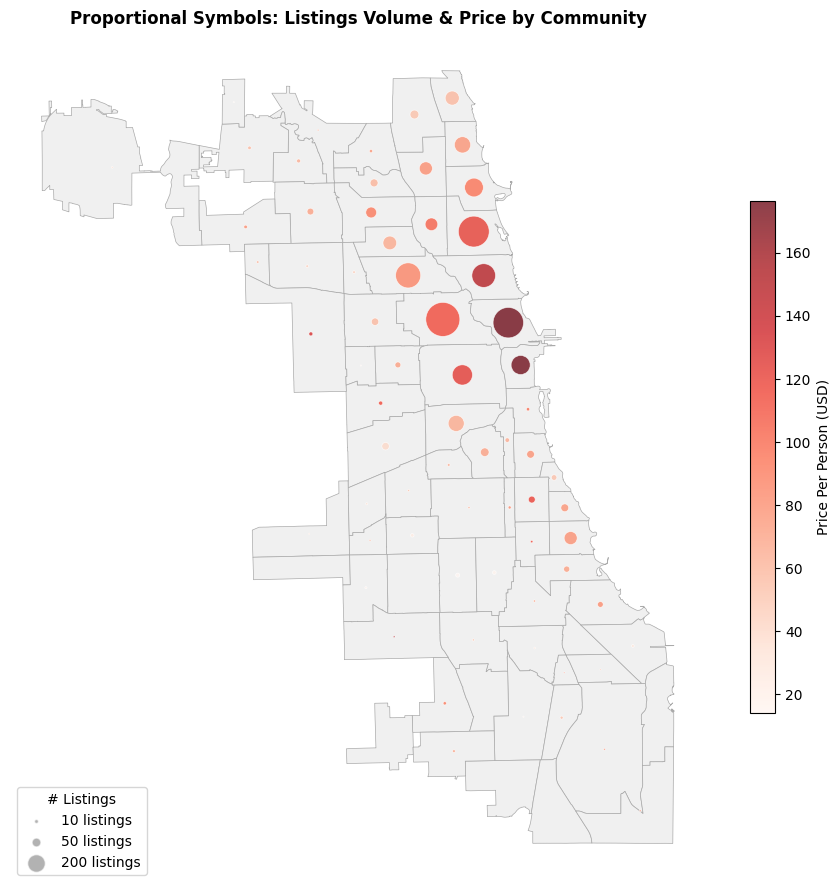

In [18]:
# Airbnb price (per person average) and number of listings by community
 
centroids = data.to_crs(epsg=32616).copy()          # project to metric CRS first
centroids["geometry"] = centroids.geometry.centroid  # centroid in meters → accurate
centroids = centroids.to_crs(data.crs)               # reproject back for plotting
 
fig, ax = plt.subplots(figsize=(9, 9))
data.plot(ax=ax, color="#f0f0f0", edgecolor="#aaa", linewidth=0.5)
 
# Size based on num_spots; color based on price_pp
max_spots = centroids["num_spots"].max()
sizes = (centroids["num_spots"] / max_spots * 600).fillna(10)
 
norm = Normalize(vmin=data["price_pp"].min(), vmax=data["price_pp"].max())
cmap = plt.get_cmap("YlOrRd")

colors = centroids["price_pp"].apply(lambda v: cmap(norm(v)) if pd.notna(v) else "grey")
 
sc = ax.scatter(
    centroids.geometry.x,
    centroids.geometry.y,
    s=sizes,
    c=centroids["price_pp"],
    cmap="Reds",
    alpha=0.75,
    edgecolors="white",
    linewidths=0.5,
    zorder=5,
)
plt.colorbar(sc, ax=ax, label="Price Per Person (USD)", shrink=0.6)
 
# Size legend
for n in [10, 50, 200]:
    ax.scatter([], [], s=(n / max_spots * 600), c="grey", alpha=0.6,
               label=f"{n} listings", edgecolors="white")
ax.legend(title="# Listings", loc="lower left", framealpha=0.8)
 
ax.set_title("Proportional Symbols: Listings Volume & Price by Community",
             fontsize=12, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("images/1_abnb_c_prop_listings_and_price", bbox_inches="tight")
plt.show()

Notes: The number of listings is visualized by the size of the dot. The color visualizes price per person. Some of the communities with the highest prices also have higher numbers of listings.

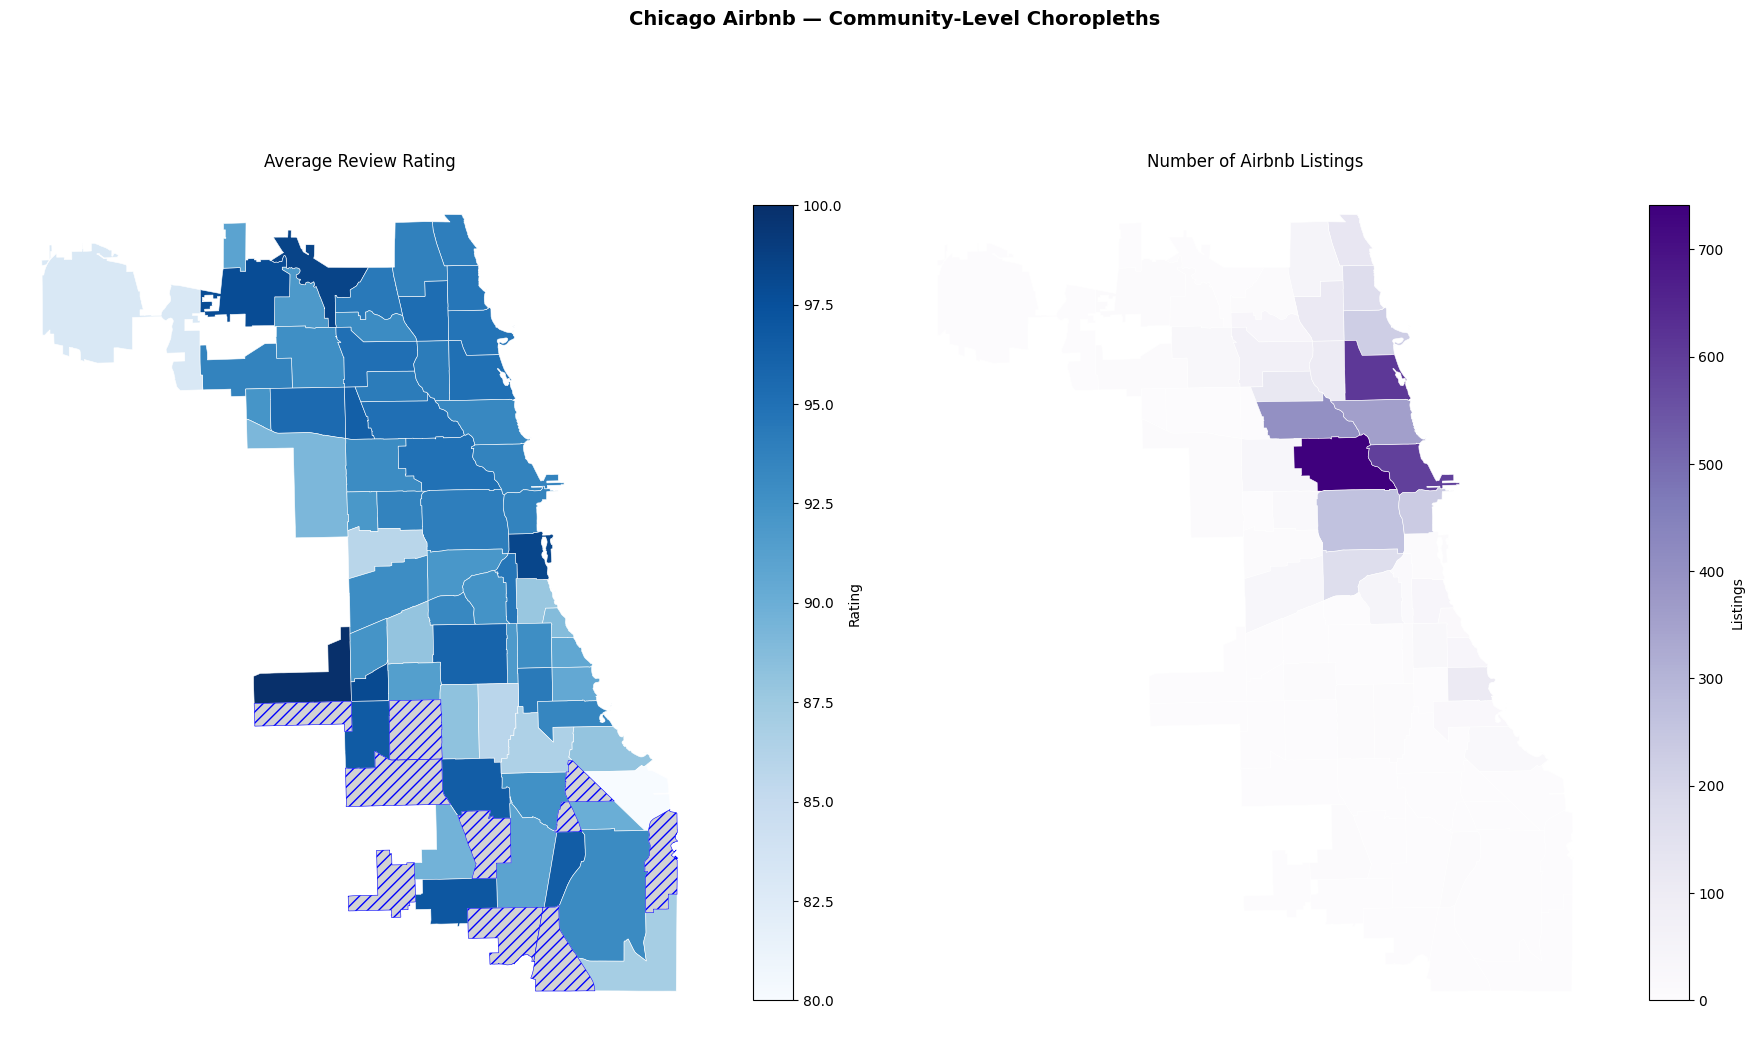

In [19]:
# choropleth maps of avg review rating and number of listings by community
 
fig, axes = plt.subplots(1, 2, figsize=(18, 12))
fig.suptitle("Chicago Airbnb — Community-Level Choropleths", fontsize=14, fontweight="bold")
 
# review rating
data.plot(
    column="rev_rating",
    cmap="Blues",
    legend=True,
    ax=axes[0],
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={"label": "Rating", "shrink": 0.7},
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "blue",
        "hatch": "///",
        "label": "Missing Values"
    },
)
axes[0].set_title("Average Review Rating")
axes[0].axis("off")
 
# number of listings
data.plot(
    column="num_spots",
    cmap="Purples",
    legend=True,
    ax=axes[1],
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={"label": "Listings", "shrink": 0.7},
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "blue",
        "hatch": "///",
        "label": "Missing Values"
    }
)
axes[1].set_title("Number of Airbnb Listings")
axes[1].axis("off")
 
plt.tight_layout()
plt.savefig("images/1_abnb_d_reviews_listings.png", bbox_inches="tight")
plt.show()

Notes: The average review ratings show that most accommodations have at least 90%. One community, Garfield Ridge, has a 100% review rating, however, below I show how many listings this community had in 2015.

The “Number of Airbnb Listings” choropleth shows a lot of light colors, making it hard to see most of the communities. Most communities do not have very many listings while some have hundreds. 

In [20]:
# find highest rating
highest_rating = data["rev_rating"].max()
# get name of community
highest_rating_name = data.loc[data["rev_rating"]==highest_rating, "community"].iloc[0]
# get number of listings from that community
highest_rating_spots = data.loc[data["community"] == highest_rating_name, "num_spots"].iloc[0]

print("~" * 100)
print(f"{highest_rating_name} community has the highest review rating ({highest_rating}%) and has {highest_rating_spots} listing(s).")
print("~" * 100)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
GARFIELD RIDGE community has the highest review rating (100.0%) and has 1 listing(s).
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [21]:
# find highest number of listings
highest_listing = data["num_spots"].max()
# get name of community
highest_listing_name = data.loc[data["num_spots"] == highest_listing, "community"].iloc[0]
# get review rating from that community
highest_listing_rate = data.loc[data["community"] == highest_listing_name, "rev_rating"].iloc[0]

print("~" * 100)
print(f"{highest_listing_name} community has the highest number of listings ({highest_listing}) and has a {round(highest_listing_rate, 2)}% rating.")
print("~" * 100)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
WEST TOWN community has the highest number of listings (741) and has a 94.93% rating.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


### Price Per Person Analysis - Price Bins

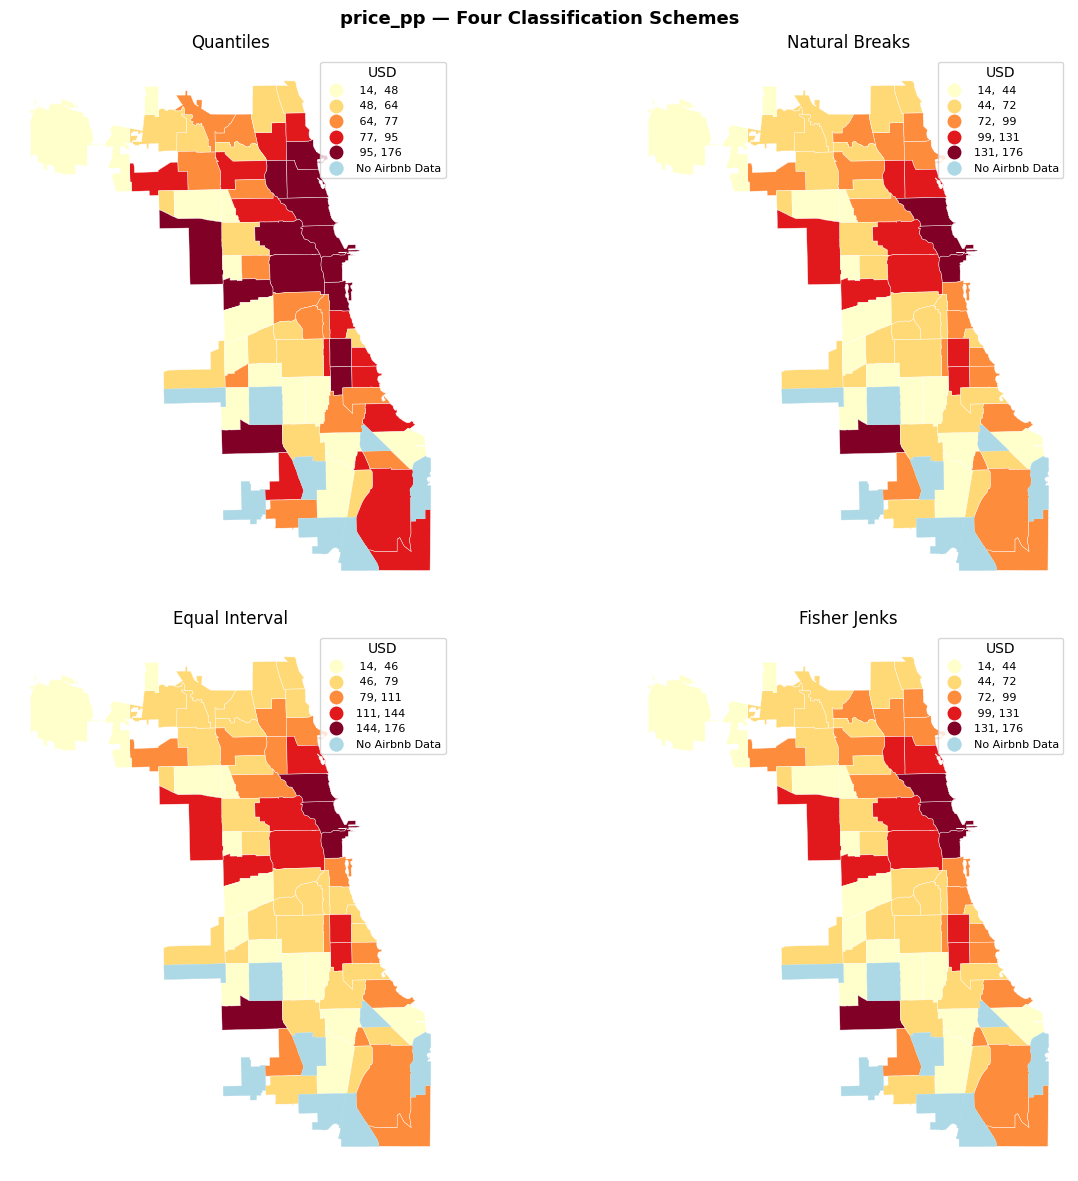

In [22]:
# choropleth of price per person using mapclassify's algorithms to break up data differently

# mapclassify (soft dependency of geopandas) uses schemes as the algorithms in each choropleth
schemes = ["quantiles", "natural_breaks", "equal_interval", "fisher_jenks"]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("price_pp — Four Classification Schemes", fontsize=13, fontweight="bold")

for ax, scheme in zip(axes.flatten(), schemes):
    data.plot(
        column="price_pp",
        scheme=scheme,
        k=5,
        cmap="YlOrRd",
        legend=True,
        ax=ax,
        edgecolor="white",
        linewidth=0.3,
        legend_kwds={"fmt": "{:.0f}", "title": "USD", "fontsize": 8},
        missing_kwds={
        "color": "lightblue",
        "edgecolor": "lightblue",
        "label": "No Airbnb Data"
    }
    )
    ax.set_title(scheme.replace("_", " ").title(), fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.savefig("images/1_abnb_e_price_classification_schemes.png", bbox_inches="tight")
plt.show()

Notes: Each choropleth separates and categorizes the price per person differently.
- **Quantiles**: an equal number of values are placed into each price ‘bin’. Here the prices are split into  5 groups: each group has the same number of communities.
- **Natural Breaks**: each price class is determined on the natural breaks of the numbers. Here, the first bin contains communities where the average price person is between `$14` and `$44`. This algorithm looks for ‘clusters’ of data points and places them based on their proximity to other points, in this case there are five bins.
- **Fisher Jenks**: very similar to natural breaks, and in this case the bins are exactly the same as “Natural Breaks” choropleth.
- **Equal Interval**: this algorithm takes the maximum and subtracts the minimum and then divides all the values into five classes.

The Quantile choropleth is the most different from the others. The bins tend to have either less range or more range. The lower value bins are grouped within about `$10-20` of each other. The highest value bin has an `$80` difference from the lower threshold to the higher threshold. This means that more of the communities are grouped in this bin than are grouped in the highest bins of the other algorithms, since those ranges aren’t as broad. 


## Socio-Economic Indicators

Now for the social and economic factors from these communities. These indicators come from the US census as well as data compiled from the city Chicago data portal. Analyzing the socio-economic dynamics of each community could highlight reasons for higher Airbnb prices, the number of listings available, the overall demographic of each community, and some of the challenges the population faces.

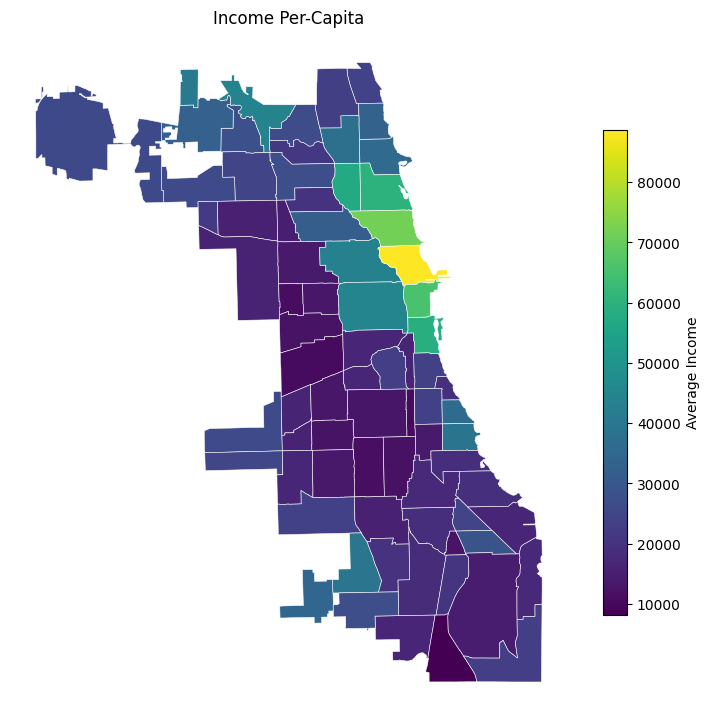

In [23]:
fig, ax = plt.subplots(figsize=(9, 9))
# fig.suptitle("Income Per-Capita", fontsize=14, fontweight="bold")

# 1. population
data.plot(
    column="income_pc",
    cmap="viridis",
    legend=True,
    ax=ax,
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={"label": "Average Income", "shrink": 0.7}
)

ax.set_title("Income Per-Capita")
ax.axis("off")
plt.savefig("images/2_se_a_income_pc.png", bbox_inches="tight")
plt.show()

Notes: This choropleth shows the average income in each community. One community in particular has the starkest difference in income; Near North Side community has a per-capita income of `$88,669`; more than $`17,000` more than the second highest. The income per-capita decreases the further each community is from the Near North Side. Most communities are well below `$30,000`. This choropleth really highlights the disparity of per-capita income between communities.

### Per-Capita Income: Top 5 Communities

In [24]:
top_5_income = data.sort_values("income_pc", ascending=False).head()
top_5_income = top_5_income[["community", "income_pc"]]
top_5_income

,community,income_pc
36,NEAR NORTH SIDE,88669
67,LINCOLN PARK,71551
37,LOOP,65526
56,LAKE VIEW,60058
33,NEAR SOUTH SIDE,59077


### Per-Capita Income: Bottom 5 Communities

In [25]:
bottom_5_income = data.sort_values("income_pc").head()
bottom_5_income = bottom_5_income[["community", "income_pc"]]
bottom_5_income

,community,income_pc
50,RIVERDALE,8201
31,SOUTH LAWNDALE,10402
2,FULLER PARK,10432
26,WEST GARFIELD PARK,10934
64,WEST ENGLEWOOD,11317


### Community Level Choropleths of Chicago - By Community

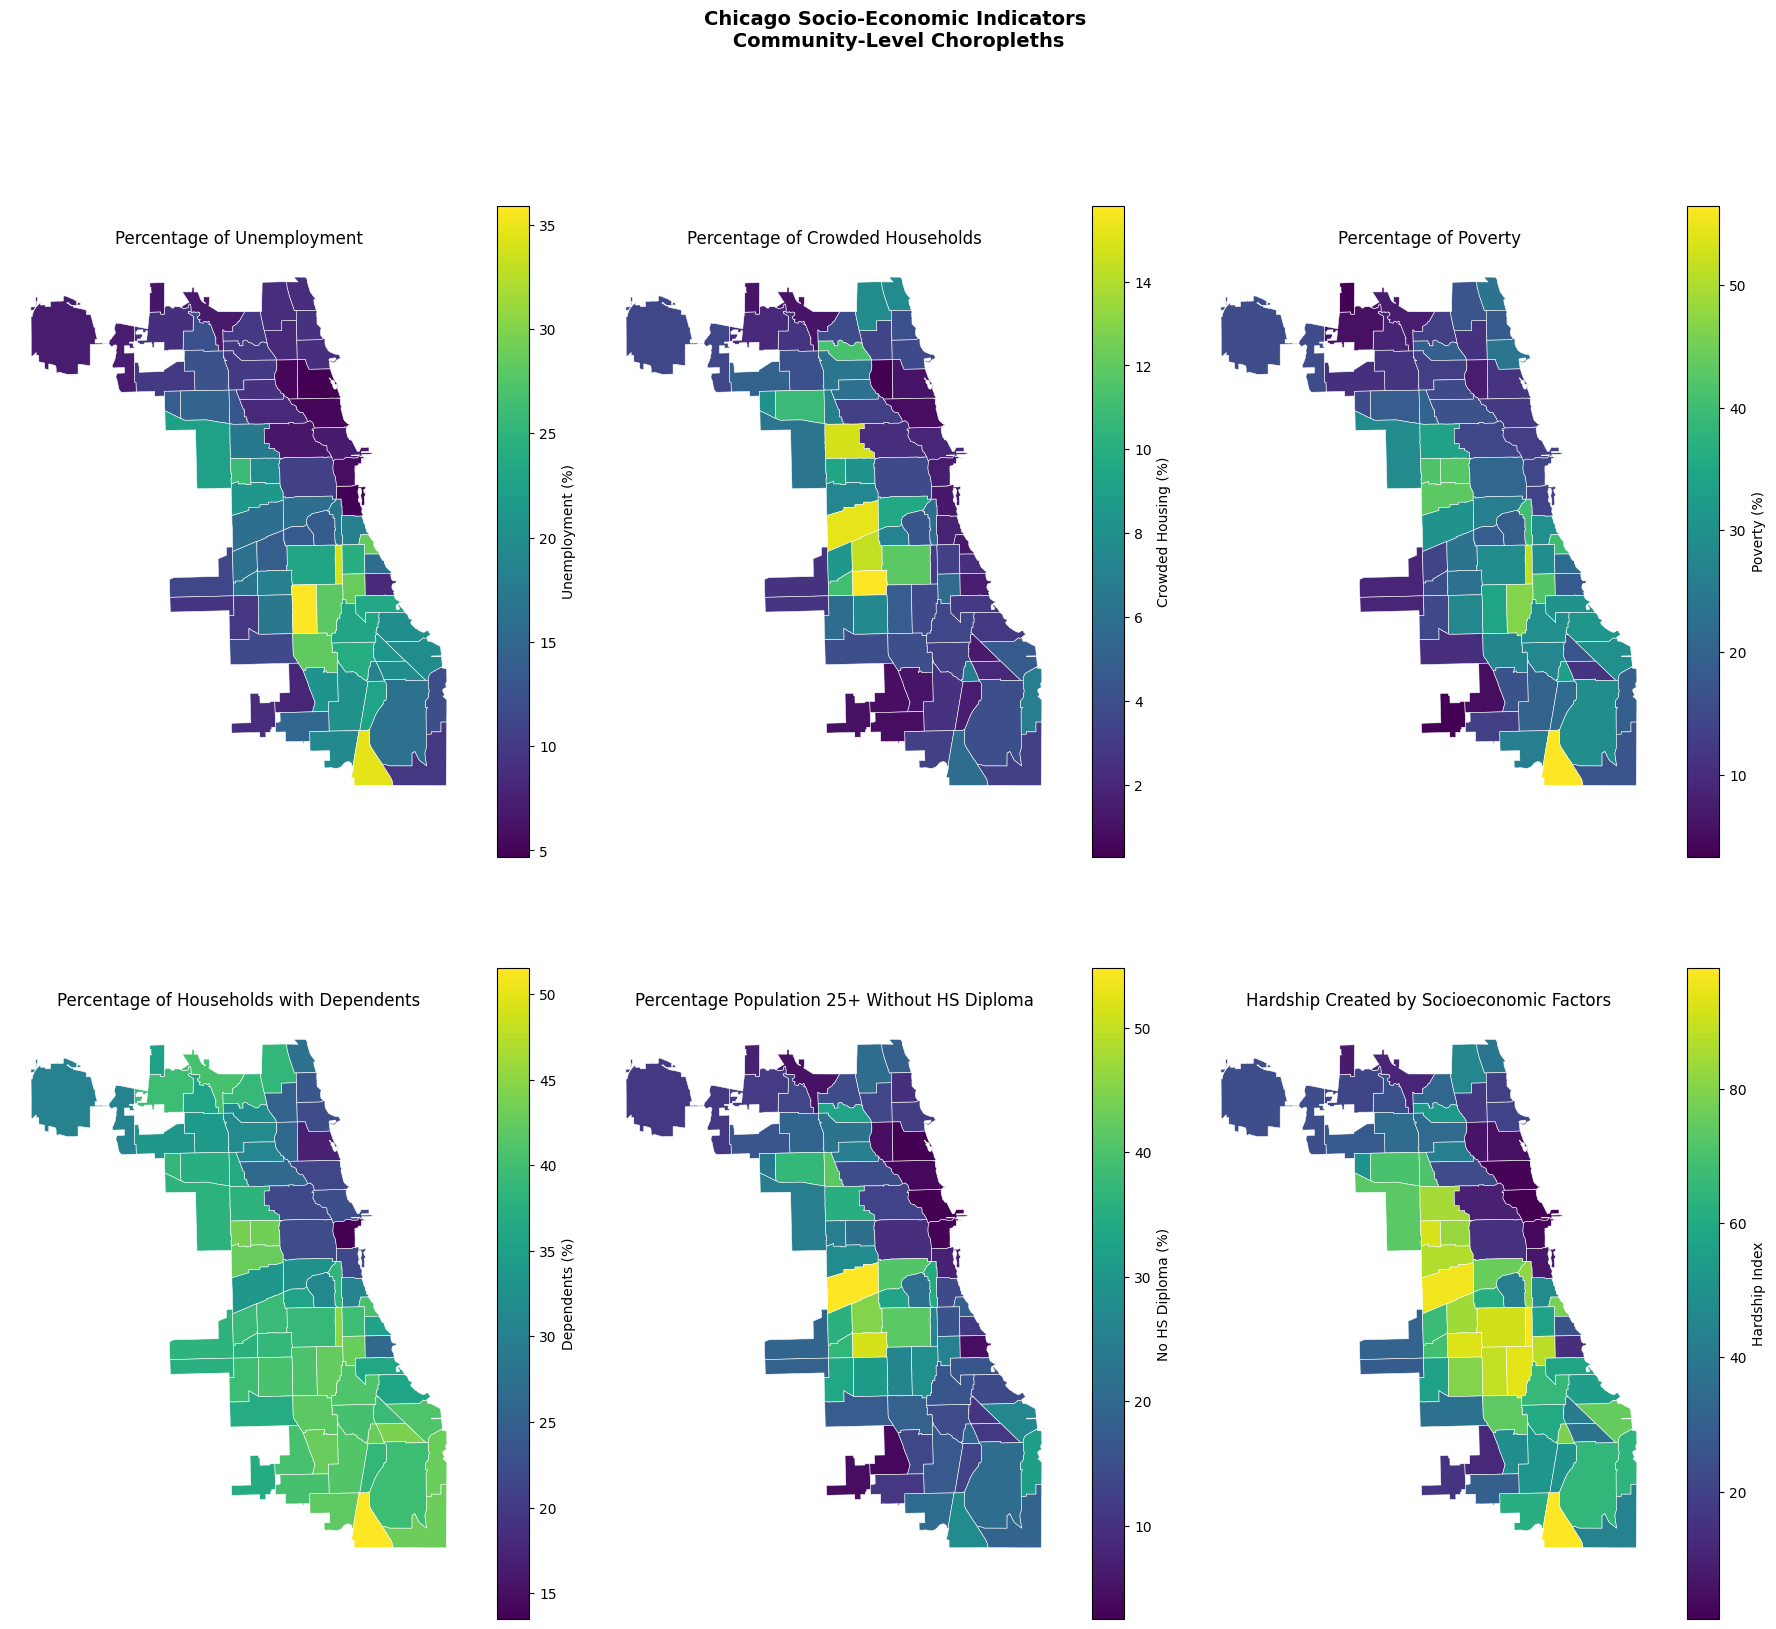

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 18))
fig.suptitle("Chicago Socio-Economic Indicators\n Community-Level Choropleths\n", fontsize=14, fontweight="bold")

# 1. population
data.plot(
    column="unemployed",
    cmap="viridis",
    legend=True,
    ax=axes[0, 0],
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={"label": "Unemployment (%)", "shrink": 0.7}
)
axes[0, 0].set_title("Percentage of Unemployment")
axes[0, 0].axis("off")

# 2. crowded housing
data.plot(
    column="crowded",
    cmap="viridis",
    legend=True,
    ax=axes[0, 1],
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={"label": "Crowded Housing (%)", "shrink": 0.7}
)
axes[0, 1].set_title("Percentage of Crowded Households")
axes[0, 1].axis("off")

# 3. poverty
data.plot(
    column="poverty",
    cmap="viridis",
    legend=True,
    ax=axes[0, 2],
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={"label": "Poverty (%)", "shrink": 0.7}
)
axes[0, 2].set_title("Percentage of Poverty")
axes[0, 2].axis("off")

# 4. households with dependents
data.plot(
    column="dependency",
    cmap="viridis",
    legend=True,
    ax=axes[1, 0],
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={"label": "Dependents (%)", "shrink": 0.7}
)
axes[1, 0].set_title("Percentage of Households with Dependents")
axes[1, 0].axis("off")

# 5. adults 25+ years without HS diploma
data.plot(
    column="without_hs",
    cmap="viridis",
    legend=True,
    ax=axes[1, 1],
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={"label": "No HS Diploma (%)", "shrink": 0.7}
)
axes[1, 1].set_title("Percentage Population 25+ Without HS Diploma")
axes[1, 1].axis("off")

# 6. hardship index based on above criteria
data.plot(
    column="hardship_in",
    cmap="viridis",
    legend=True,
    ax=axes[1, 2],
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={"label": "Hardship Index", "shrink": 0.7},
)
axes[1, 2].set_title("Hardship Created by Socioeconomic Factors")
axes[1, 2].axis("off")

plt.tight_layout()
plt.savefig("images/2_se_b_socio_eco_indicators.png", bbox_inches="tight")
plt.show()


### Socio-Economic Indicators - Notes

- **Unemployment**: The unemployment rates within each of the communities are somewhat clustered. Communities with higher rates of unemployment tend to be in the southern part of Chicago, while the communities with lower unemployment tend to be towards the north side, along the coast of Lake Michigan. According to the US  Bureau of Labor Statistics, in 2012 Chicago’s unemployment rate (as a whole) was `8.9%` and the entire U.S. rate was `8.1%`. https://www.bls.gov/k12/students/maps/data/laus-2012-ann-avg-unemp-data.htm#k12_laus_ann_avg_unemp.xls.f.1  
- **Crowded Households**: this is a percentage of the housing units where more than one person resides in each room. Some community populations have greater than `12%` of the housing where multiple people are sharing a room. 
- **Poverty**: poverty for this dataset means that a household is living below the federal poverty level; in 2012 the official poverty threshold for a family of four was `$23,050`. One community in particular has well over `50%` poverty and several others hover around `30-45%`. According to the US Census Bureau, poverty is defined as pre-tax income that does not cover a household’s expenses (given certain threshold criteria). (https://www.census.gov/topics/income-poverty/poverty/guidance/poverty-measures.html) (https://aspe.hhs.gov/2012-poverty-guidelines-federal-register-notice)
- **Dependency**: the definition for ‘dependency’ in this dataset is the percentage of the population that would be considered a dependent, such as children (under 18 years) or elderly relatives (over the age of 64. Most communities have between 35-45% dependents, while some have less than 20%.
- **Without HS Diploma**: several communities have higher rates of people over the age of 25 that do not have a high school diploma. This generally equates to lower income compared to high school graduates or GED holders, as well as fewer career options. (https://www.bls.gov/careeroutlook/2018/article/no-formal-education-outlook.htm).
- **Hardship Index**: According to the Chicago Health Atlas, the hardship index is calculated based on economic and social hardships: crowded housing (more than one person per room), poverty rates, unemployment, high school diploma holders, age dependency ratio (% of dependents vs. those of working age), and per-capita income. The index ranges from 0 to 100 and can help governments and organizations understand the dynamics of some areas compared to others. (https://chicagohealthatlas.org/indicators/HDX)

### Poverty: Top 5 Communities

In [27]:
top_5_poverty = data.sort_values("poverty", ascending=False).head()
top_5_poverty = top_5_poverty[["community", "poverty", "income_pc", "unemployed", "crowded", "dependency", "without_hs", "hardship_in"]]
top_5_poverty

,community,poverty,income_pc,unemployed,crowded,dependency,without_hs,hardship_in
50,RIVERDALE,56.5,8201,34.6,5.8,51.5,27.5,98
2,FULLER PARK,51.2,10432,33.9,3.2,44.9,26.6,97
65,ENGLEWOOD,46.6,11888,28.0,3.8,42.5,28.5,94
29,NORTH LAWNDALE,43.1,12034,21.2,7.4,42.7,27.6,87
27,EAST GARFIELD PARK,42.4,12961,19.6,8.2,43.2,21.3,83


### Poverty: Bottom 5 Communities

In [28]:
bottom_5_poverty = data.sort_values("poverty").head()
bottom_5_poverty = bottom_5_poverty[["community", "poverty", "income_pc", "unemployed", "crowded", "dependency", "without_hs", "hardship_in"]]
bottom_5_poverty

,community,poverty,income_pc,unemployed,crowded,dependency,without_hs,hardship_in
76,EDISON PARK,3.3,40959,6.5,1.1,35.3,7.4,8
72,MOUNT GREENWOOD,3.4,34381,8.7,1.0,36.8,4.3,16
70,BEVERLY,5.1,39523,8.0,0.9,40.5,3.7,12
35,NORWOOD PARK,5.4,32875,9.0,2.0,39.5,11.5,21
45,NORTH CENTER,7.5,57123,5.2,0.3,26.2,4.5,6


Thoughts on highest and lowest poverty:
- Communities with the highest poverty rates also have higher rates of dependency, percentage of adults without a high school diploma, and moderately elevated levels of crowded housing. These communities are all in the lower levels of income per-capita, as well. All these communities also have some of the highest levels of hardship index scores.
- Communities with the lowest poverty rates have lower levels of the other socio-economic indicators except income per-capita.

## Income Per-Capita Relationships

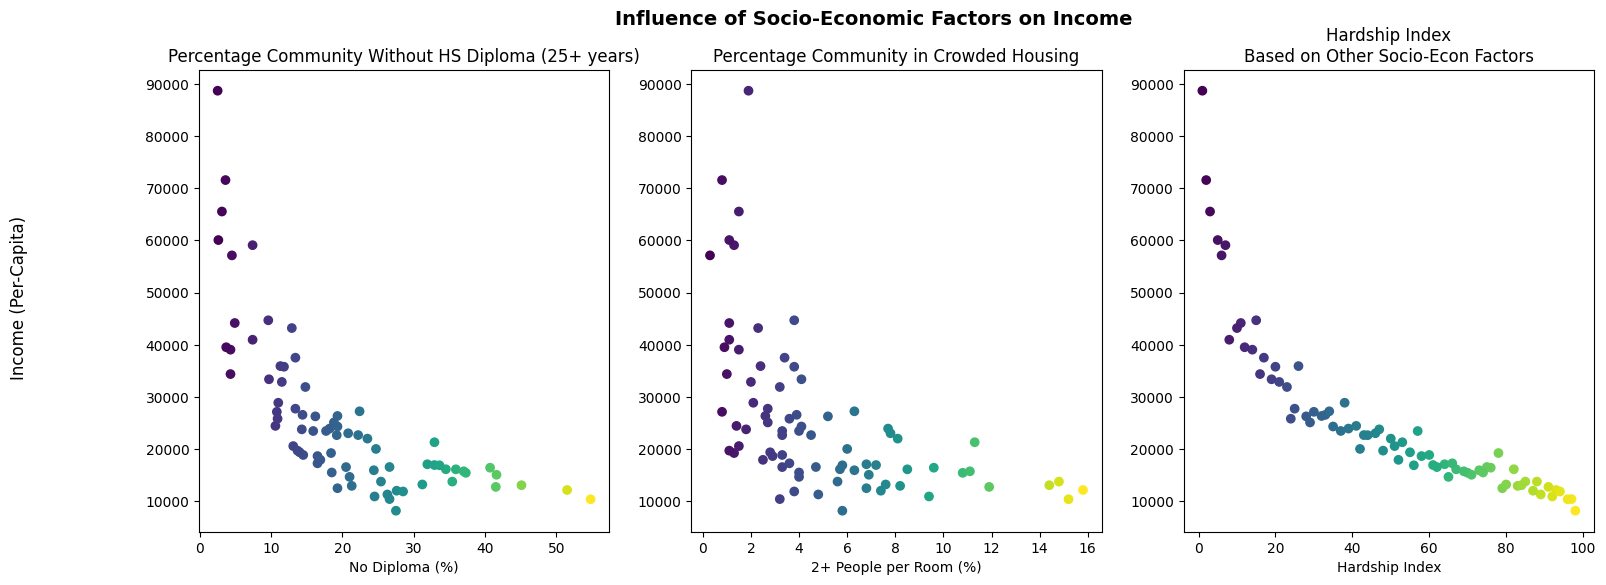

In [29]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Influence of Socio-Economic Factors on Income", fontsize=14, fontweight="bold")

ax1.scatter(
    x=data["without_hs"],
    y=data["income_pc"],
    c=data["without_hs"],
    cmap="viridis"
)
ax1.set_xlabel("No Diploma (%)")
ax1.set_title("Percentage Community Without HS Diploma (25+ years)")

ax2.scatter(
    x=data["crowded"],
    y=data["income_pc"],
    c=data["crowded"],
    cmap="viridis"
)
ax2.set_xlabel("2+ People per Room (%)")
ax2.set_title("Percentage Community in Crowded Housing")

ax3.scatter(
    x=data["hardship_in"],
    y=data["income_pc"],
    c=data["hardship_in"],
    cmap="viridis"
)
ax3.set_xlabel("Hardship Index")
ax3.set_title("Hardship Index\nBased on Other Socio-Econ Factors")

fig.supylabel("Income (Per-Capita)")
plt.savefig("images/2_se_c_income_scatter.png", bbox_inches="tight")
plt.show()

These scatter plots show a negative correlation between income per-capita and the other socio-economic factors. Communities with the highest levels of income per-capita also have the lowest rates of adults without a high school diploma, some of the lowest percentages of crowded housing, and have the lowest hardship index scores as well.

# Airbnb Analysis With Socio-Economic Factors

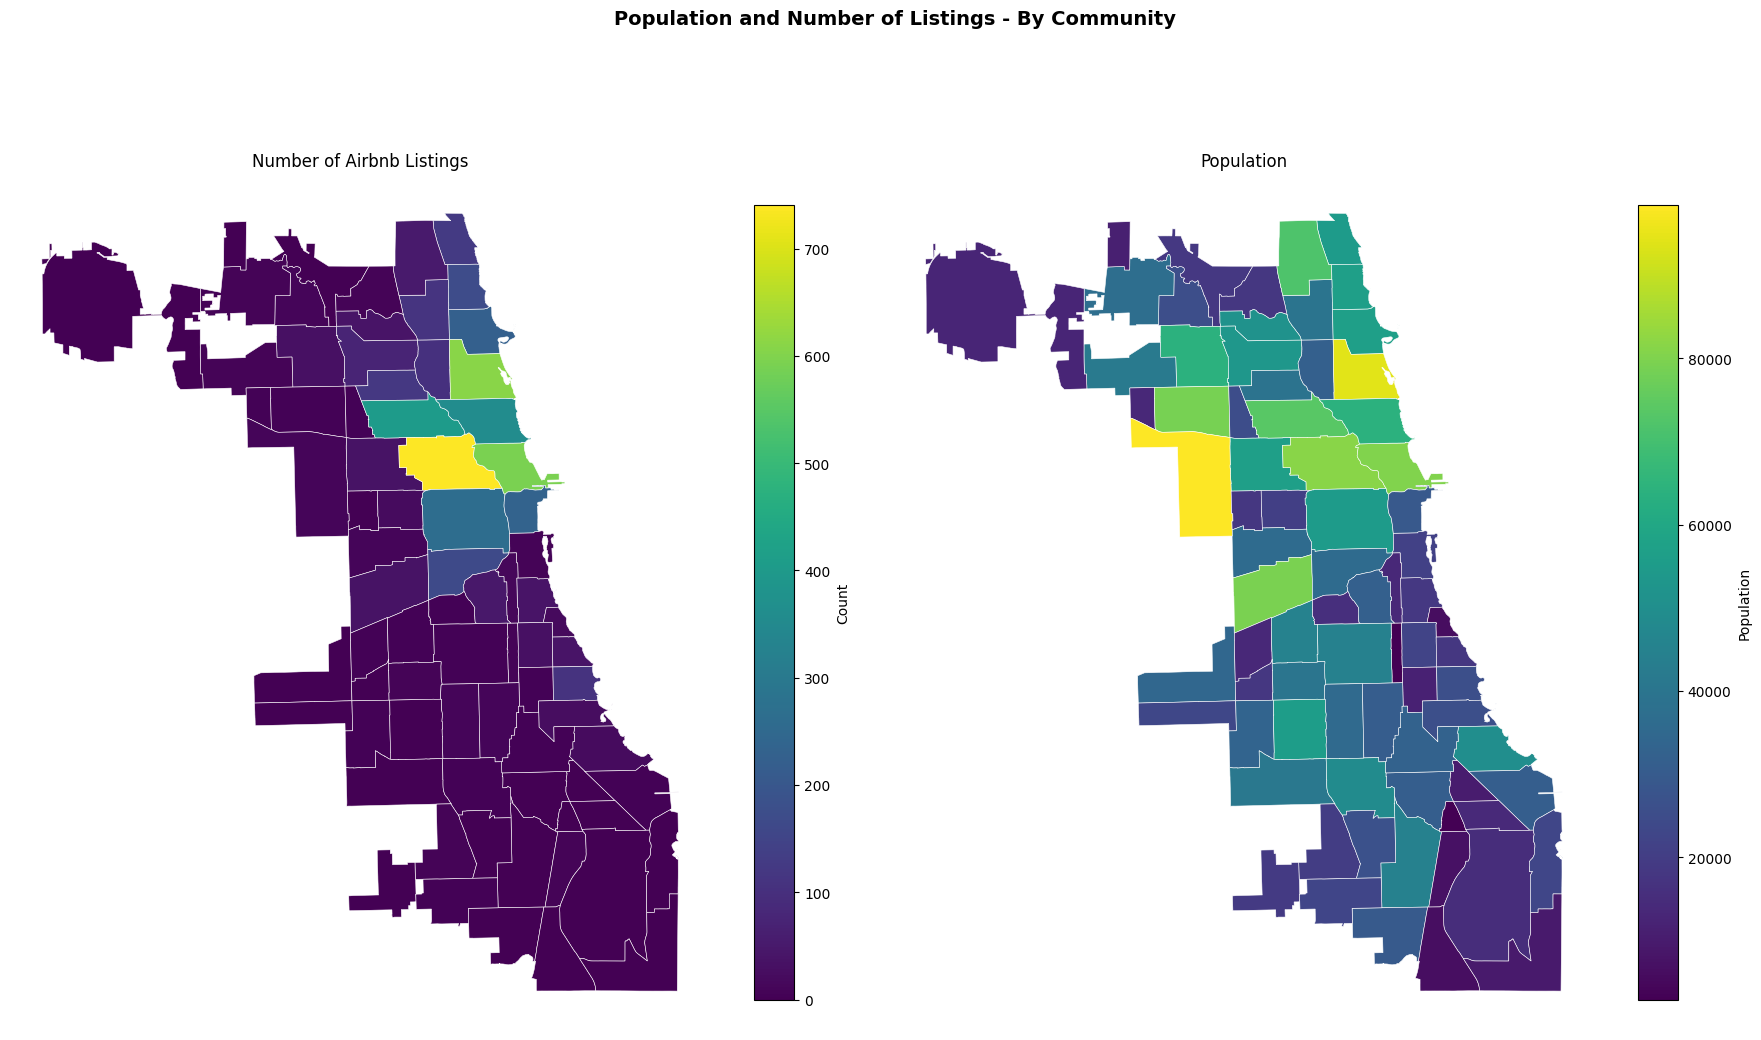

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 12))
fig.suptitle("Population and Number of Listings - By Community", fontsize=14, fontweight="bold")

# 1. airbnb listings
data.plot(
    column="num_spots",
    cmap="viridis",
    legend=True,
    ax=axes[0],
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={"label": "Count", "shrink": 0.7}
)
axes[0].set_title("Number of Airbnb Listings")
axes[0].axis("off")

# 2. crowded housing
data.plot(
    column="population",
    cmap="viridis",
    legend=True,
    ax=axes[1],
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={"label": "Population", "shrink": 0.7}
)
axes[1].set_title("Population")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("images/3_both_a_listings_population_choropleth.png", bbox_inches="tight")
plt.show()

Notes: The communities with higher numbers of Airbnb listings tend to have larger populations.

### Airbnb Listings: Top 5 Communities

In [31]:
top_5_listings = data.sort_values("num_spots", ascending=False).head()
top_5_listings = top_5_listings[["community", "num_spots", "population"]]
top_5_listings

,community,num_spots,population
24,WEST TOWN,741,81432
56,LAKE VIEW,609,94368
36,NEAR NORTH SIDE,593,80484
22,LOGAN SQUARE,404,73595
67,LINCOLN PARK,358,64116


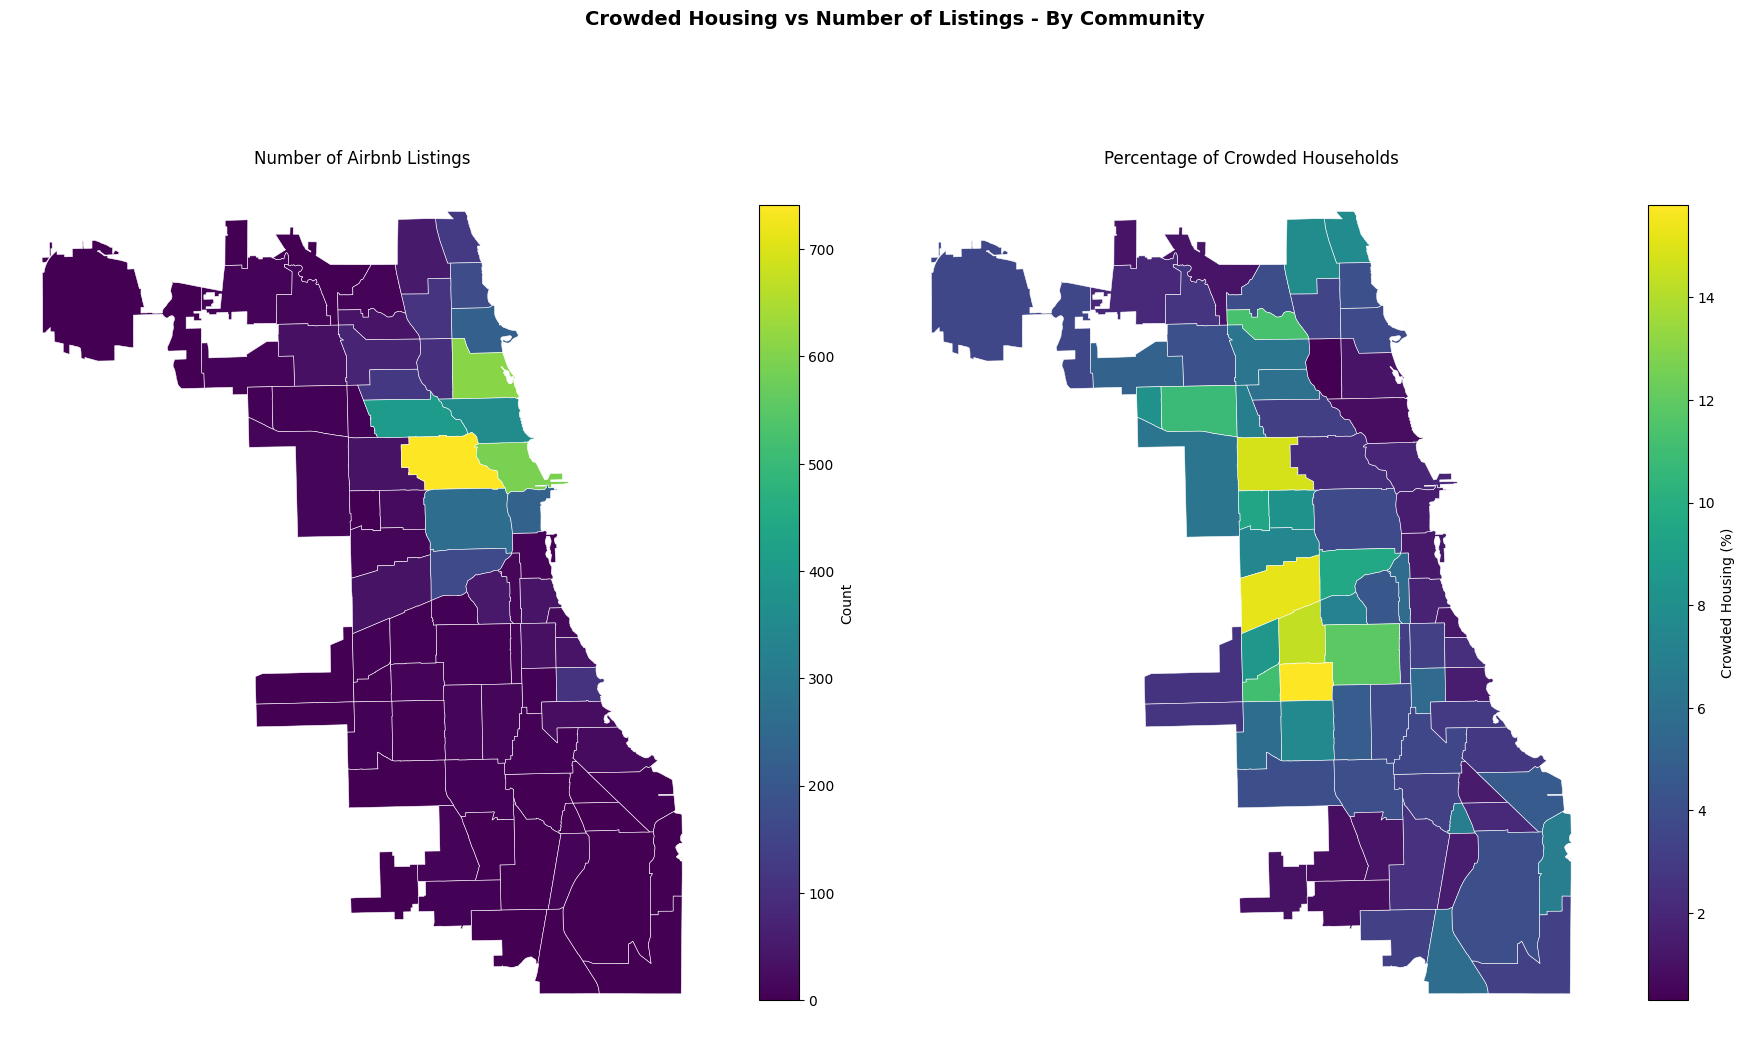

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(18, 12))
fig.suptitle("Crowded Housing vs Number of Listings - By Community", fontsize=14, fontweight="bold")

# 1. airbnb listings
data.plot(
    column="num_spots",
    cmap="viridis",
    legend=True,
    ax=axes[0],
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={"label": "Count", "shrink": 0.7}
)
axes[0].set_title("Number of Airbnb Listings")
axes[0].axis("off")

# 2. crowded housing
data.plot(
    column="crowded",
    cmap="viridis",
    legend=True,
    ax=axes[1],
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={"label": "Crowded Housing (%)", "shrink": 0.7}
)
axes[1].set_title("Percentage of Crowded Households")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("images/3_both_b_listings_crowdedhousing_choropleth.png", bbox_inches="tight")
plt.show()

Notes: The communities with higher numbers of Airbnb listings tend to be those with much lower rates of crowded housing.

### Crowded Housing: Top 5 Communities

In [33]:
top_5_crowded = data.sort_values("crowded", ascending=False).head()
top_5_crowded = top_5_crowded[["community", "crowded", "num_spots", "population"]]
top_5_crowded

,community,crowded,num_spots,population
60,GAGE PARK,15.8,8,39894
31,SOUTH LAWNDALE,15.2,36,79288
23,HUMBOLDT PARK,14.8,35,56323
54,BRIGHTON PARK,14.4,3,45368
58,NEW CITY,11.9,3,44377


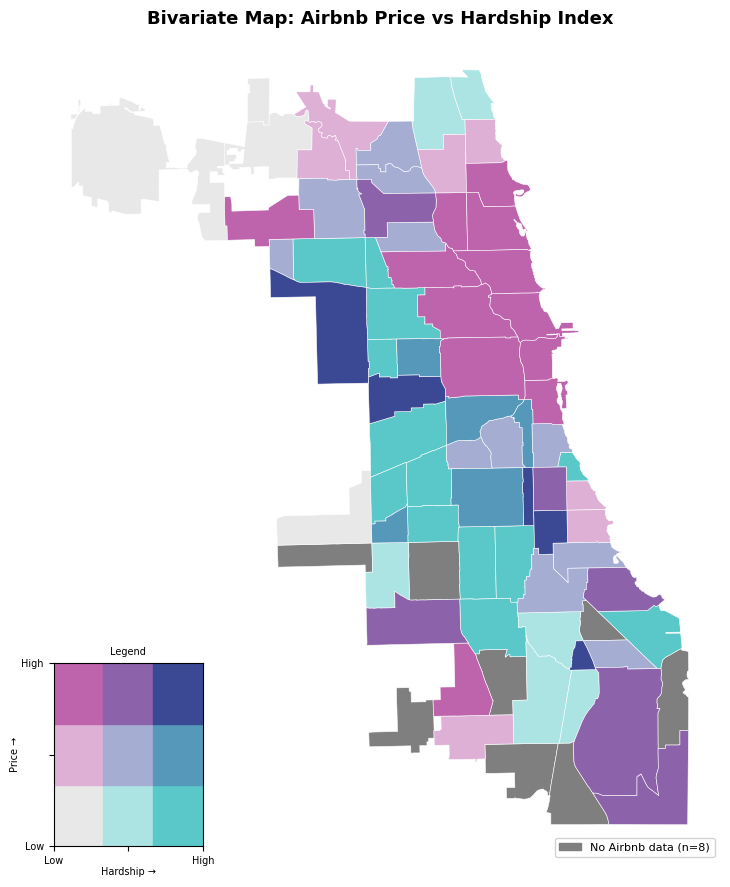

In [34]:
# bivariate map: hardship index values and airbnb price per person

def bivariate_class(series1, series2, n=3):
    """Classify two variables into n×n grid (0-indexed)."""
    q1 = pd.qcut(series1, n, labels=False, duplicates="drop")
    q2 = pd.qcut(series2, n, labels=False, duplicates="drop")
    return q1.astype(float) * n + q2.astype(float)
 
# Bivariate palette (3×3 = 9 classes)
bv_colors = [
    "#e8e8e8", "#ace4e4", "#5ac8c8",   # low price / low→high hardship
    "#dfb0d6", "#a5add3", "#5698b9",   # mid price
    "#be64ac", "#8c62aa", "#3b4994",   # high price / low→high hardship
]

data_bv = data.copy()

# variable holds only data without NaN values 
valid = data_bv["price_pp"].notna() & data_bv["hardship_in"].notna()

# explicitly NaN for all rows first to help differentiate missing Airbnb data
data_bv["bv_class"] = np.nan
data_bv.loc[valid, "bv_class"] = bivariate_class(
    data_bv.loc[valid, "price_pp"], data_bv.loc[valid, "hardship_in"]
)

fig, ax = plt.subplots(figsize=(9, 9))

# draw 'no data' areas first so bivariate colors never paint over them
no_data = data_bv[~valid]
if not no_data.empty:
    no_data.plot(ax=ax, color="#7f7f7f", edgecolor="white", linewidth=0.4)

# draw bivariate classes on top
for cls, color in enumerate(bv_colors):
    subset = data_bv[data_bv["bv_class"] == cls]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor="white", linewidth=0.4)

# bivariate legend (3×3 grid)
inset_ax = ax.inset_axes([0.02, 0.02, 0.22, 0.22])
for r in range(3):
    for c in range(3):
        rect = mpatches.Rectangle((c, r), 1, 1, color=bv_colors[r * 3 + c])
        inset_ax.add_patch(rect)
inset_ax.set_xlim(0, 3); inset_ax.set_ylim(0, 3)
inset_ax.set_xticks([0, 1.5, 3]); inset_ax.set_yticks([0, 1.5, 3])
inset_ax.set_xticklabels(["Low", "", "High"], fontsize=7)
inset_ax.set_yticklabels(["Low", "", "High"], fontsize=7)
inset_ax.set_xlabel("Hardship →", fontsize=7, labelpad=1)
inset_ax.set_ylabel("Price →", fontsize=7, labelpad=1)
inset_ax.set_title("Legend", fontsize=7)

# add explicit 'no data' legend
if not no_data.empty:
    handles = [mpatches.Patch(color="#7f7f7f", label=f"No Airbnb data (n={len(no_data)})")]
    ax.legend(handles=handles, loc="lower right", framealpha=0.85, fontsize=8)

ax.set_title("Bivariate Map: Airbnb Price vs Hardship Index", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("images/3_both_c_bivariate_price_hardship.png", bbox_inches="tight")
plt.show()

Notes: Some of the highest Airbnb prices have the lowest hardship index scores, and vis versa. A few communities have high Airbnb prices and high hardship scores.

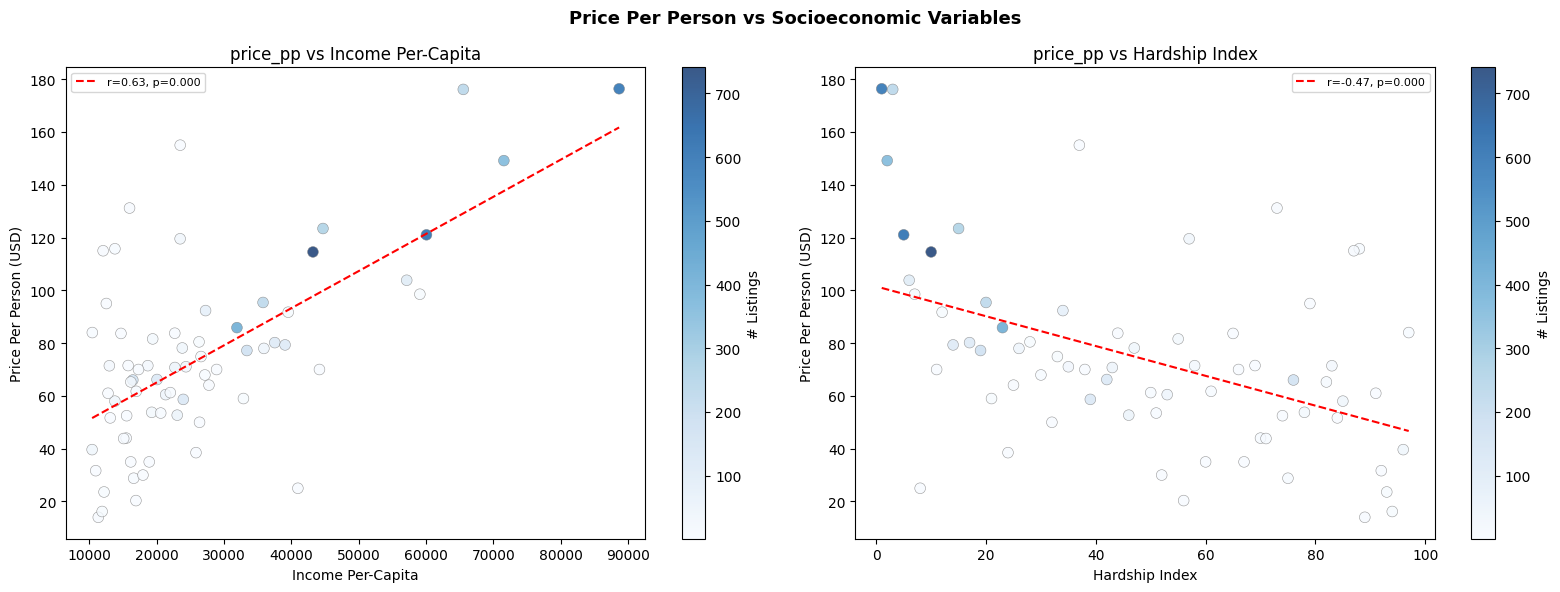

In [35]:
# Price per person plotted against income per-capita and hardship index, with number of listings highlighted
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Price Per Person vs Socioeconomic Variables", fontsize=13, fontweight="bold")
 
pairs = [
    ("income_pc", "Income Per-Capita"),
    ("hardship_in", "Hardship Index"),
]
colors_scatter = data["num_spots"].fillna(0)
 
for ax, (xcol, xlabel) in zip(axes, pairs):
    valid = data[[xcol, "price_pp", "num_spots"]].dropna()
    sc = ax.scatter(
        valid[xcol], valid["price_pp"],
        c=valid["num_spots"], cmap="Blues", alpha=0.8,
        s=60, edgecolors="grey", linewidths=0.4,
    )
    plt.colorbar(sc, ax=ax, label="# Listings")
 

    slope, intercept, r, p, _ = stats.linregress(valid[xcol], valid["price_pp"])
    xline = np.linspace(valid[xcol].min(), valid[xcol].max(), 100)
    ax.plot(xline, slope * xline + intercept, "r--", lw=1.5,
            label=f"r={r:.2f}, p={p:.3f}")
    ax.legend(fontsize=8)
 
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Price Per Person (USD)")
    ax.set_title(f"price_pp vs {xlabel}")
 
plt.tight_layout()
plt.savefig("images/3_both_d_scatter_socioeconomic.png", bbox_inches="tight")
plt.show()

- **Price Per Person - Income**: The higher rates of income per-capita have a positive correlation with Airbnb price, as well as higher numbers of listings.

- **Price Per Person - Hardship Index**: The price per person has a negative correlation with hardship index scores; the scatterplot shows that communities with higher prices tend to have the lowest hardship scores. However, there are some points that indicate some communities have higher prices as well as a high hardship index.


# Crime Data

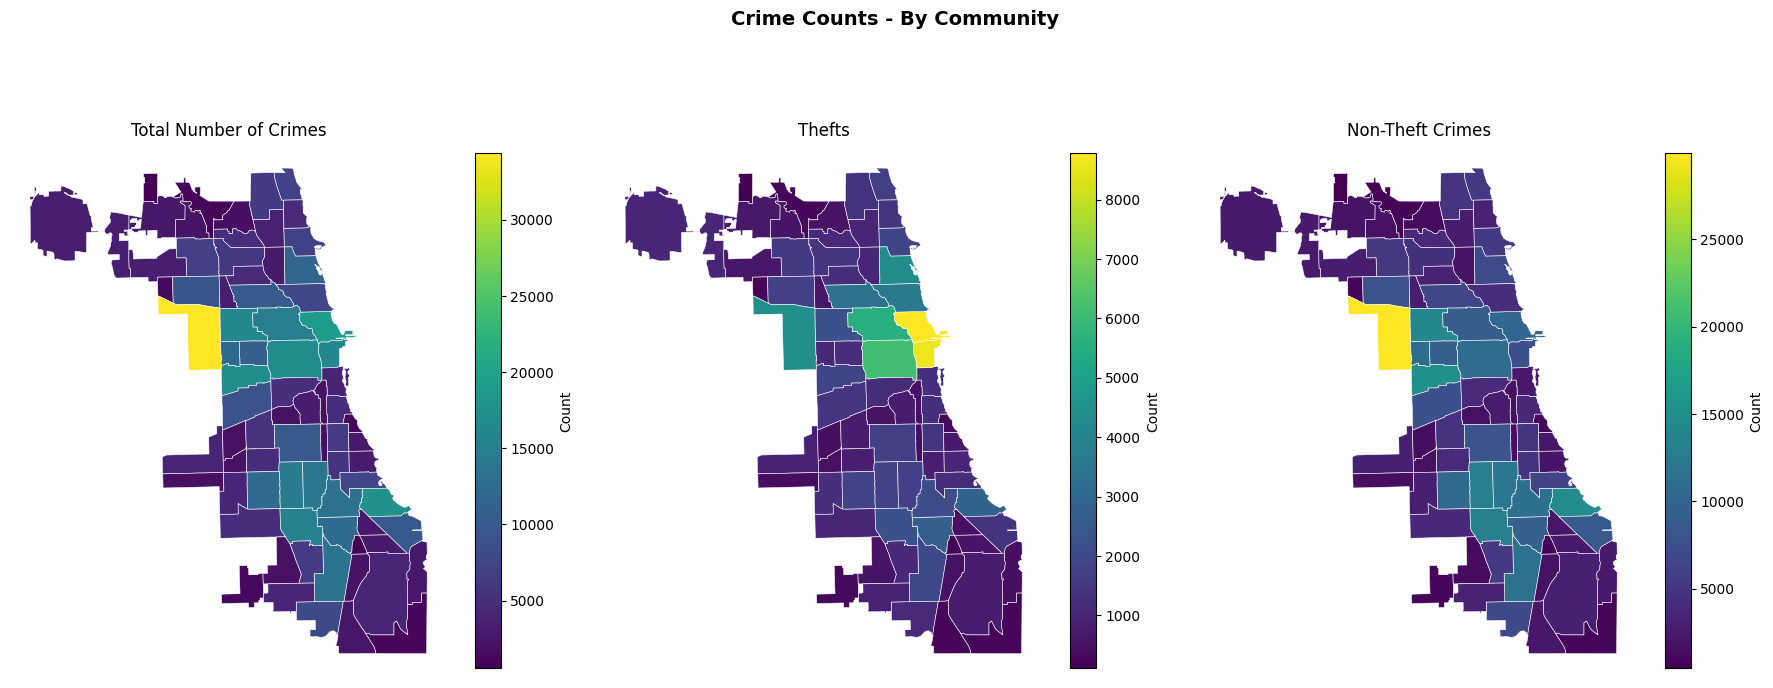

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
fig.suptitle("Crime Counts - By Community", fontsize=14, fontweight="bold")

# 1. total number of crimes
data.plot(
    column="total_crimes",
    cmap="viridis",
    legend=True,
    ax=axes[0],
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={"label": "Count", "shrink": 0.7}
)
axes[0].set_title("Total Number of Crimes")
axes[0].axis("off")

# 2. thefts
data.plot(
    column="num_theft",
    cmap="viridis",
    legend=True,
    ax=axes[1],
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={"label": "Count", "shrink": 0.7}
)
axes[1].set_title("Thefts")
axes[1].axis("off")

# 3. other crimes
data.plot(
    column="num_non_theft",
    cmap="viridis",
    legend=True,
    ax=axes[2],
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={"label": "Count", "shrink": 0.7}
)
axes[2].set_title("Non-Theft Crimes")
axes[2].axis("off")


plt.tight_layout()
plt.savefig("images/4_crime_counts.png", bbox_inches="tight")
plt.show()

### Total Crimes: Top 5 Communities

In [37]:
top_5_crime_communities = data.sort_values("total_crimes", ascending=False).head()
top_5_crime_communities = top_5_crime_communities[["community", "total_crimes", "num_theft", "num_non_theft"]]
top_5_crime_communities

,community,total_crimes,num_theft,num_non_theft
25,AUSTIN,34365,4442,29923
36,NEAR NORTH SIDE,18947,8783,10164
38,SOUTH SHORE,17466,2783,14683
29,NORTH LAWNDALE,16980,1873,15107
28,NEAR WEST SIDE,16873,6143,10730


### Thefts: Top 5 Communities

In [38]:
top_5_theft_communities = data.sort_values("num_theft", ascending=False).head()
top_5_theft_communities = top_5_theft_communities[["community", "num_theft", "num_non_theft", "total_crimes"]]
top_5_theft_communities

,community,num_theft,num_non_theft,total_crimes
36,NEAR NORTH SIDE,8783,10164,18947
37,LOOP,8557,7481,16038
28,NEAR WEST SIDE,6143,10730,16873
24,WEST TOWN,5552,9153,14705
25,AUSTIN,4442,29923,34365


### Top 10 Communities by Income and Number of Thefts

In [39]:
theft_v_income = data.sort_values("income_pc", ascending=False).head(10)
theft_v_income = theft_v_income[["community", "income_pc", "num_theft"]]
theft_v_income

,community,income_pc,num_theft
36,NEAR NORTH SIDE,88669,8783
67,LINCOLN PARK,71551,3646
37,LOOP,65526,8557
56,LAKE VIEW,60058,4296
33,NEAR SOUTH SIDE,59077,1250
45,NORTH CENTER,57123,995
28,NEAR WEST SIDE,44689,6143
11,FOREST GLEN,44164,257
24,WEST TOWN,43198,5552
76,EDISON PARK,40959,104


Note: The community with the highest income per-capita also has the highest number of thefts.

## Correlation Analysis

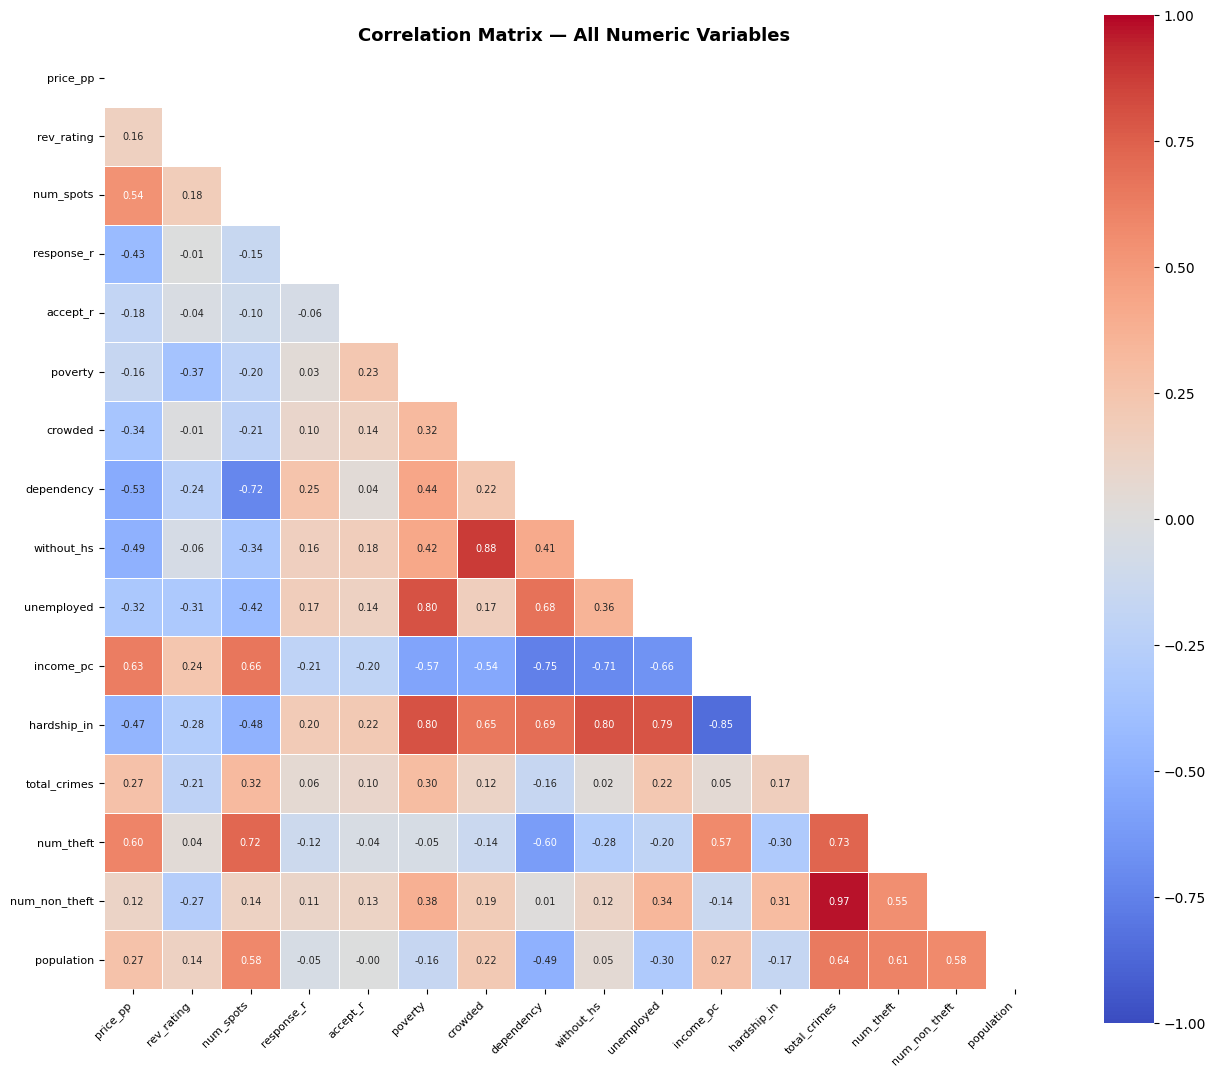

In [40]:
# correlation map between numeric columns (non-geographical data)
 
numeric_cols = [
    "price_pp", "rev_rating", "num_spots", "response_r", "accept_r",
    "poverty", "crowded", "dependency", "without_hs", "unemployed",
    "income_pc", "hardship_in", "total_crimes", "num_theft", "num_non_theft", "population",
]
corr = data[numeric_cols].corr()
 
fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap="coolwarm", center=0,
    vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.5, ax=ax, square=True,
)
ax.set_title("Correlation Matrix — All Numeric Variables", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("images/5_correlation_heatmap.png", bbox_inches="tight")
plt.show()
 
# Key insight printout
# print("\nTop correlations with price_pp:")
# print(corr["price_pp"].drop("price_pp").sort_values(key=abs, ascending=False).head(10))

### Correlation Heatmap Insights
**Price**: 

Strongest Positive Correlations:
- income per capita
- number of thefts
- number of listings

Strongest Negative Correlations:
- percentage of dependency
- percentage of adults without high school diploma
- hardship index score

**Poverty**:

Strongest Positive Correlation:
- percentage of unemployment
- hardship index score

Strongest Negative Correlation:
- income per-capita



Top 5 most expensive communities:
      community   price_pp  rev_rating  num_spots  income_pc  hardship_in  total_crimes  population  crimes_per_1k
NEAR NORTH SIDE 176.375604   93.649007        593      88669            1         18947       80484          235.4
           LOOP 176.131821   93.635294        233      65526            3         16038       29283          547.7
   LINCOLN PARK 149.147253   93.223368        358      71551            2          7793       64116          121.5
         AUSTIN 131.175000   89.200000         10      15957           73         34365       98514          348.8
 NEAR WEST SIDE 123.423028   94.049020        262      44689           15         16873       54881          307.4

Bottom 5 least expensive communities:
     community  price_pp  rev_rating  num_spots  income_pc  hardship_in  total_crimes  population  crimes_per_1k
   EDISON PARK 25.000000   91.000000          1      40959            8           537       11187           48.0
     GAGE 

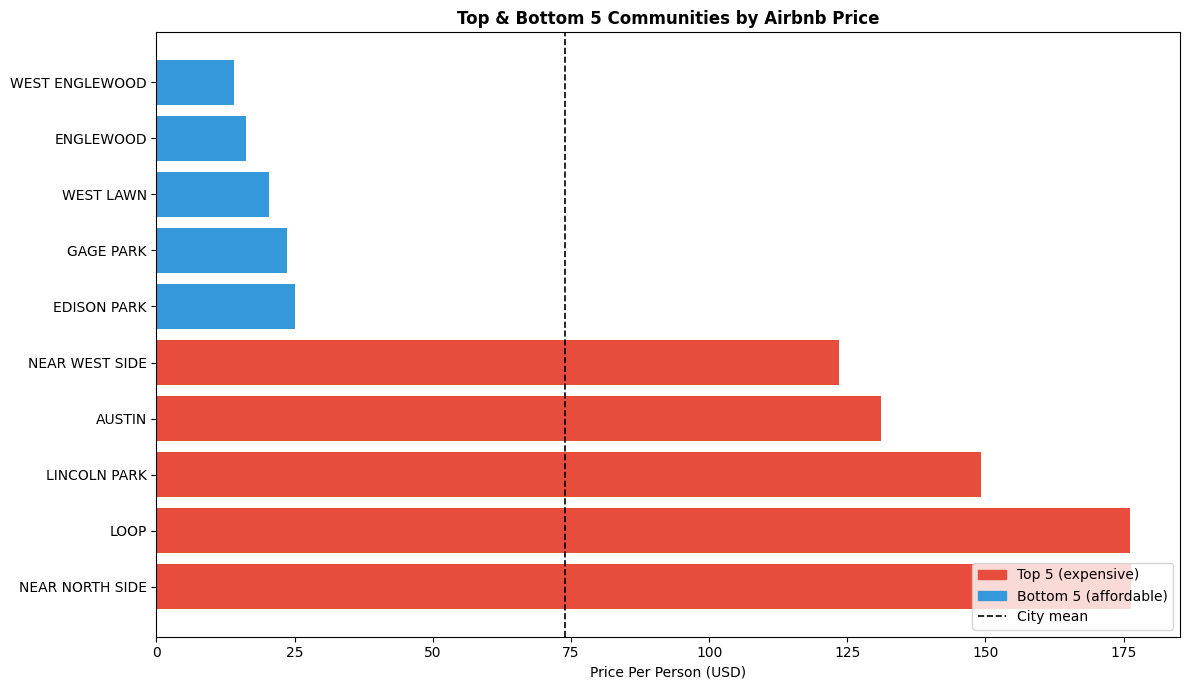

In [41]:
# Summary of Airbnb Prices by Community (5 most expensive and 5 least expensive)
 
summary = data[[
    "community", "price_pp", "rev_rating", "num_spots",
    "income_pc", "hardship_in", "total_crimes", "population"
]].copy()

# several communities have no airbnb data, drop these na values 
summary = summary.dropna() 

summary["crimes_per_1k"] = (summary["total_crimes"] / summary["population"] * 1000).round(1)
summary = summary.sort_values("price_pp", ascending=False)
 
print("\nTop 5 most expensive communities:")
print(summary.head(5).to_string(index=False))
 
print("\nBottom 5 least expensive communities:")
print(summary.tail(5).to_string(index=False))
 
# Bar chart: top/bottom 5 price
top5  = summary.head(5)
bot5  = summary.tail(5)
combined = pd.concat([top5, bot5])
 
fig, ax = plt.subplots(figsize=(12, 7))
colors_bar = ["#e74c3c" if x in top5["community"].values else "#3498db"
              for x in combined["community"]]
ax.barh(combined["community"], combined["price_pp"], color=colors_bar)
ax.axvline(data["price_pp"].mean(), color="black", linestyle="--", lw=1.2, label="City mean")
ax.set_xlabel("Price Per Person (USD)")
ax.set_title("Top & Bottom 5 Communities by Airbnb Price", fontsize=12, fontweight="bold")
ax.legend()
top_patch = mpatches.Patch(color="#e74c3c", label="Top 5 (expensive)")
bot_patch = mpatches.Patch(color="#3498db", label="Bottom 5 (affordable)")
ax.legend(handles=[top_patch, bot_patch, plt.Line2D([0],[0],color="black",ls="--",lw=1.2,label="City mean")],
          loc="lower right")
plt.tight_layout()
plt.savefig("images/5_price_summary.png", bbox_inches="tight")
plt.show()


## Summary of Analysis

Based on the available data and an analysis of the socio-economic factors of communities in Chicago, there are several key insights about the demographics of the region and how it might have affected the Airbnb listings in 2015. The communities with higher incomes per capita tended to have a greater number of listings, as well as more expensive prices per person. Communities with higher rates of poverty, unemployment, crowded housing, dependency, and adults without high school diplomas tended to have less expensive prices for Airbnb listings.